# Оптимизация выполнения кода, векторизация, Numba

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Макрушин С.В. "Оптимизация выполнения кода, векторизация, Numba"
* IPython Cookbook, Second Edition (2018), глава 4
* https://ipython-books.github.io/43-profiling-your-code-line-by-line-with-line_profiler/
* https://numba.pydata.org/numba-doc/latest/user/5minguide.html
* https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-reflection-for-list-and-set-types

## Задачи для совместного разбора

In [15]:
# !pip install git+https://github.com/pyutils/line_profiler.git
# !pip install line_profiler
# !pip install --user numpy==1.20

In [16]:
import numpy as np
import numba
from numba import njit

1. Сгенерируйте массив `A` из `N=1млн` случайных целых чисел на отрезке от 0 до 1000. Пусть `B[i] = A[i] + 100`. Посчитайте среднее значение массива `B`.

In [17]:
%%time
N = 1000000
A = np.random.randint(0, 1000, size=N)
B = np.zeros_like(A)
for i in A:
    B[i] = A[i] + 100
B.mean()

CPU times: user 519 ms, sys: 17.5 ms, total: 536 ms
Wall time: 592 ms


0.601394

In [19]:
%%time
@njit
def f(A):
    B = np.zeros_like(A)
    for i in A:
        B[i] = A[i] + 100
    return B.mean()

f(A)

CPU times: user 134 ms, sys: 7.84 ms, total: 142 ms
Wall time: 160 ms


0.601394

2. Напишите функцию, которая возвращает сумму всех чисел от 0 до x-1. Примените функцию к каждому элементу массива.

3. Создайте таблицу 2млн строк и с 4 столбцами, заполненными случайными числами. Добавьте столбец `key`, которые содержит элементы из множества английских букв. Выберите из таблицы подмножество строк, для которых в столбце `key` указаны первые 5 английских букв.

In [ ]:
%load_ext line_profiler

In [20]:
import pandas as pd
import string

N = 2_000_000
df = pd.DataFrame(np.random.randn(N, 4), columns=[f"col{i}" for i in range(4)])
df["key"] = np.random.choice(list(string.ascii_letters.lower()), N, replace=True)
df.head(2)

,col0,col1,col2,col3,key
0,-1.249519,-0.146550,0.278958,-0.164519,s
1,-0.540130,1.097074,0.685254,0.596930,b


## Лабораторная работа 8

In [21]:
import numpy as np
import pandas as pd
from numba import jit, njit
import numba
from typing import Union

%load_ext line_profiler

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


В файлах `recipes_sample.csv` и `reviews_sample.csv` (__ЛР 2__) находится информация об рецептах блюд и отзывах на эти рецепты соответственно. Загрузите данные из файлов в виде `pd.DataFrame` с названиями `recipes` и `reviews`. Обратите внимание на корректное считывание столбца(ов) с индексами. Приведите столбцы к нужным типам.

## Измерение времени выполнения кода

Назовем полным описанием рецепта строку, полученную путем конкатенации названия и описания рецепта через пробел. Удалите строки для рецептов, которые были добавлены не в 2010 году.

Реализуйте несколько вариантов функции подсчета средней длины полного описания рецепта для рецептов, добавленных в 2010 году.

In [24]:
recipes = pd.read_csv('02_pandas_data/recipes_sample.csv', parse_dates=['submitted'])
reviews = pd.read_csv('02_pandas_data/reviews_sample.csv', parse_dates=['date'], index_col=0)

In [26]:
recipes.head(2)

,name,id,minutes,contributor_id,submitted,n_steps,description,n_ingredients
0,george s at the cove black bean soup,44123,90,35193,2002-10-25,NaN,an original recipe created by chef scott meska...,18.0
1,healthy for them yogurt popsicles,67664,10,91970,2003-07-26,NaN,my children and their friends ask for my homem...,NaN


In [27]:
recipes['full_description'] = recipes['name'] + ' ' + recipes['description']
recipes.head(2)

,name,id,minutes,contributor_id,submitted,n_steps,description,n_ingredients,full_description
0,george s at the cove black bean soup,44123,90,35193,2002-10-25,NaN,an original recipe created by chef scott meska...,18.0,george s at the cove black bean soup an origi...
1,healthy for them yogurt popsicles,67664,10,91970,2003-07-26,NaN,my children and their friends ask for my homem...,NaN,healthy for them yogurt popsicles my children...


In [33]:
recipes = recipes[recipes['submitted'].dt.year == 2010]
recipes.head()

,name,id,minutes,contributor_id,submitted,n_steps,description,n_ingredients,full_description
52,just peachy cobbler,437637,70,1085867,2010-09-17,10.0,all i can say is yummmmmm . . . a simple to ma...,10.0,just peachy cobbler all i can say is yummmmmm...
68,the heat spicy party mix,437219,95,1682162,2010-09-13,NaN,a spicy chex mix that will really warm your gu...,11.0,the heat spicy party mix a spicy chex mix tha...
81,iowa state fair sweet dough caramel cinnamon ...,435816,80,17803,2010-08-24,29.0,this was the winning entry at the 2010 iowa st...,NaN,iowa state fair sweet dough caramel cinnamon ...
104,1 minute blueberries cream,428566,2,1375473,2010-06-04,4.0,i was craving blueberry tonight but wanted non...,NaN,1 minute blueberries cream i was craving blu...
146,2 2 2 diet mocha,416599,5,789314,2010-03-15,5.0,"while trying to come up with a satisfying ""sna...",7.0,2 2 2 diet mocha while trying to come up with ...


1\.1 С использованием метода `DataFrame.iterrows` таблицы:

    - функция принимает на вход таблицу, содержащую рецепты за 2010 год;
    
    - нахождение полного описания рецепта осуществляется внутри цикла по `iterrows` для каждой строки по отдельности.

In [34]:
def get_mean_len_A(df: pd.DataFrame) -> float:
    length = 0
    count = 0
    for index, col in df.iterrows():
        length += len(col['full_description'])
        count += 1
    return length / count

get_mean_len_A(recipes)

265.501300390117

1\.2. С использованием метода `DataFrame.apply` таблицы:

    - функция принимает на вход таблицу, содержащую рецепты за 2010 год;
    
    - вызываете метод apply у таблицы, в качестве аргумента передаете функцию, которая возвращает полное описание для каждой строки;
    
    - считаете среднюю длину описаний, вызвав соответствующий метод серии.

In [36]:
def get_mean_len_B(df: pd.DataFrame) -> float:
    return df.apply(lambda x: len(x['full_description']), axis=1).mean()

get_mean_len_B(recipes)

265.501300390117

In [38]:
def get_mean_len_B(df: pd.DataFrame) -> float:
  table = (df["name"] +" "+df["description"]).apply(len)
  return table.mean()
get_mean_len_B(recipes)

265.501300390117

1\.3. С использованием векторизованных методов серий `pd.Series`:

    - функция принимает на вход таблицу, содержащую рецепты за 2010 год;
    
    - при помощи векторизированных операций получаете столбец с полным описанием;
    
    - при помощи векторизированных операций получаете длины полного описания;
    
    - при помощи метода серий получаете среднюю длину полных описаний. 

In [40]:
def get_mean_len_C(df: pd.DataFrame) -> float:
  return (df['name'] + " " + df['description']).str.len().mean()

get_mean_len_C(recipes)

265.501300390117

1.4 Проверьте, что результаты работы всех написанных функций корректны и совпадают. Измерьте выполнения всех написанных функций при помощи магических команд `time` и `timeit`.

## Анализ пошагового выполнения кода 

Вам предлагается воспользоваться функцией, которая собирает статистику о том, сколько отзывов содержат то или иное слово. 

In [41]:
import re


def get_word_reviews_count(df):
    word_reviews = {}
    for _, row in df.dropna(subset=["review"]).iterrows():
        recipe_id, review = row["recipe_id"], row["review"]
        words = re.sub("[^A-Za-z\s]", "", review).split(" ")
        for word in words:
            if word not in word_reviews:
                word_reviews[word] = []
            word_reviews[word].append(recipe_id)

    word_reviews_count = {}
    for _, row in df.dropna(subset=["review"]).iterrows():
        review = row["review"]
        words = re.sub("[^A-Za-z\s]", "", review).split(" ")
        for word in words:
            word_reviews_count[word] = len(word_reviews[word])
    return word_reviews_count

№2.1 Найдите узкие места в коде, проанализировав код функции по шагам, используя профайлер. Сохраните результаты работы профайлера в отдельную текстовую ячейку. Выпишите (словами), что в имеющемся коде реализовано неоптимально. 

In [ ]:
%lprun -f get_word_reviews_count get_word_reviews_count(reviews)

 **В одной функции дублируются циклы, что делает программу крайне неоптимальной. Плюс ко всему используется метод iterrows, который как мы выяснили выше, занимает больше всего времени**

№2.2  Оптимизируйте функцию и добейтесь значительного (как минимум, в 5 раз) прироста в скорости выполнения. Для демонстрации результата измерьте скорость выполнения оригинальной функции и функции, написанной вами.

In [ ]:
%%time
get_word_reviews_count(reviews)

CPU times: user 27.6 s, sys: 184 ms, total: 27.8 s
Wall time: 29.6 s


{'last': 4517,
 'week': 1489,
 'whole': 5540,
 'sides': 435,
 'of': 61867,
 'frozen': 2722,
 'salmon': 819,
 'fillet': 86,
 'was': 56972,
 'on': 28791,
 'sale': 255,
 'in': 43940,
 'my': 44544,
 'local': 565,
 'supermarket': 93,
 'so': 39441,
 'i': 101329,
 'bought': 1490,
 'tons': 184,
 'okay': 717,
 'only': 13679,
 '': 89125,
 'but': 36936,
 'total': 557,
 'weight': 290,
 'over': 8762,
 'pounds': 275,
 'this': 83593,
 'recipe': 54531,
 'is': 41236,
 'perfect': 8643,
 'for': 75829,
 'even': 8881,
 'though': 4791,
 'it': 73971,
 'calls': 513,
 'steaks': 434,
 'cut': 6416,
 'up': 14352,
 'the': 95894,
 'into': 6364,
 'individual': 304,
 'portions': 209,
 'and': 97007,
 'followed': 5450,
 'instructions': 971,
 'exactly': 4678,
 'im': 7768,
 'one': 15973,
 'those': 2408,
 'food': 3473,
 'combining': 82,
 'diets': 45,
 'left': 4958,
 'out': 22223,
 'white': 3493,
 'wine': 1580,
 'added': 19387,
 'just': 23483,
 'a': 84192,
 'dash': 617,
 'vinegar': 1641,
 'instead': 11221,
 'little': 14634

In [ ]:
def get_word_reviews_count_opt(df):
    word_reviews = {}
    words = df.dropna(subset=["review"])["review"].str.replace(r"[^A-Za-z\s]", "").str.lower().str.split(" ").values
    for list_words in words:
        for word in list_words:
            if word not in word_reviews:
                word_reviews[word] = 0
    for list_words in words:
        for word in list_words:
            word_reviews[word] += 1
    return word_reviews

In [ ]:
s = get_word_reviews_count(reviews)

In [ ]:
s2 = get_word_reviews_count_opt(reviews)

<ipython-input-63-fe9762fa59f2>:3: FutureWarning: The default value of regex will change from True to False in a future version.
  words = df.dropna(subset=["review"])["review"].str.replace(r"[^A-Za-z\s]", "").str.lower().str.split(" ").values


In [ ]:
%%time
get_word_reviews_count_opt(reviews)

<ipython-input-63-fe9762fa59f2>:3: FutureWarning: The default value of regex will change from True to False in a future version.
  words = df.dropna(subset=["review"])["review"].str.replace(r"[^A-Za-z\s]", "").str.lower().str.split(" ").values


CPU times: user 5.09 s, sys: 25.9 ms, total: 5.12 s
Wall time: 5.21 s


{'last': 4703,
 'week': 1544,
 'whole': 5916,
 'sides': 463,
 'of': 109547,
 'frozen': 2967,
 'salmon': 1105,
 'fillet': 94,
 'was': 90295,
 'on': 36424,
 'sale': 266,
 'in': 64015,
 'my': 59303,
 'local': 578,
 'supermarket': 95,
 'so': 52873,
 'i': 296120,
 'bought': 1541,
 'tons': 189,
 'okay': 736,
 'only': 14976,
 '': 330966,
 'but': 46147,
 'total': 575,
 'weight': 305,
 'over': 9896,
 'pounds': 292,
 'this': 133750,
 'recipe': 74513,
 'is': 57014,
 'perfect': 9192,
 'for': 125127,
 'even': 9471,
 'though': 5057,
 'it': 153087,
 'calls': 527,
 'steaks': 523,
 'cut': 6984,
 'up': 16246,
 'the': 292739,
 'into': 7115,
 'individual': 317,
 'portions': 214,
 'and': 222382,
 'followed': 5499,
 'instructions': 1020,
 'exactly': 4773,
 'im': 8620,
 'one': 18708,
 'those': 2493,
 'food': 3669,
 'combining': 82,
 'diets': 45,
 'left': 5200,
 'out': 25797,
 'white': 3822,
 'wine': 1792,
 'added': 22853,
 'just': 27706,
 'a': 172295,
 'dash': 642,
 'vinegar': 2002,
 'instead': 12557,
 'litt

In [ ]:
%lprun -f get_word_reviews_count get_word_reviews_count(reviews)

In [ ]:
%lprun -f get_word_reviews_count_opt get_word_reviews_count_opt(reviews)

<ipython-input-63-fe9762fa59f2>:3: FutureWarning: The default value of regex will change from True to False in a future version.
  words = df.dropna(subset=["review"])["review"].str.replace(r"[^A-Za-z\s]", "").str.lower().str.split(" ").values


## Numba

В файле `rating_predictions.json` хранятся данные о рейтингах рецептов и прогнозных значениях рейтингов для этого рецепта, полученных при помощи модели машинного обучения. 

Напишите несколько версий функции (см. [MAPE](https://en.wikipedia.org/wiki/Mean_absolute_percentage_error)) для расчета среднего абсолютного процентного отклонения значения рейтинга отзыва на рецепт от прогнозного значения рейтинга для данного рецепта. 


Замечание 1: в формуле MAPE под $A_t$ понимается рейтинг из отзыва $t$, под $F_t$ - прогнозное значения рейтинга отзыва $t$.

Замечание 2: в результате работы функций должно получиться одно число - MAPE для всего набора данных.

3\.1 Создайте два списка `A_list` и `F_list` на основе файла `rating_predictions.json`. Напишите функцию `mape_lists` без использования векторизованных операций и методов массивов `numpy` и без использования `numba` (проитерируйтесь по спискам и вычислите суммарное значение MAPE для всех элементов, а потом усредните результат).

Измерьте время выполнения данной функции на входных данных `A_list` и `F_list`. Временем, затрачиваемым на создание списков, можно пренебречь.
    

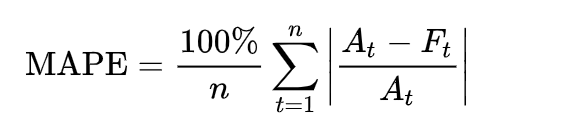

In [47]:
import pandas as pd

rating_predictions = pd.read_json('08_profiling_data/rating_predictions.json')
rating_predictions.head()

,rating,prediction
0,5,4.944444
1,5,4.437500
2,5,4.727273
3,5,4.354545
4,5,4.888889


In [53]:
A_list, F_list = list(rating_predictions["rating"]), list(rating_predictions["prediction"])

In [50]:
def mape(actual,pred):
    n = len(actual)
    s = 0
    for i in range(n):
        s += abs(actual[i] - pred[i]) / actual[i]
    print(f'''MAPE: { round(100*s / n, 2) } %''')

mape(A_list, F_list)

MAPE: 13.33 %


3\.2. Создайте массивы `numpy` `A_array` и `F_array` на основе списков `A_list` и `F_list`. Напишите функцию `mape_numpy` с использованием векторизованных операций и методов массивов `numpy`.

Измерьте время выполнения данной функции на входных данных `A_array` и `F_array`. Временем, затрачиваемым на создание массивов, можно пренебречь.

In [54]:
A_array, F_array = np.array(A_list), np.array(F_list)

In [57]:
def mape_numpy(actual, pred):
    mape =  np.mean(np.abs((actual - pred) / actual)) * 100
    print(f'''MAPE: { round(mape, 2) } %''')
mape_numpy(A_array, F_array)

MAPE: 13.33 %


3\.3. Создайте объекты `numba.typed.List` `A_typed` и `F_typed` на основе списков `A_list` и `F_list`. Напишите функцию `mape_numba` без использования векторизованных операций и методов массивов `numpy`, но с использованием `numba`. 

Измерьте время выполнения данной функции на входных данных `A_typed` и `F_typed`. Временем, затрачиваемым на создание объектов `numba.typed.List`, можно пренебречь.

Измерьте время выполнения данной функции на входных данных `A_array` и `F_array`.

In [60]:
A_typed, F_typed = numba.typed.List(A_list), numba.typed.List(F_list)

@njit
def mape_numba(actual, pred):
    mape = 0
    for i in range(len(actual)):
        mape += abs((actual[i] - pred[i]) / actual[i])
    return  round((mape/len(actual) * 100), 2)

mape_numba(A_typed, F_typed)    

13.33

## Векторизация

Сайт-агрегатор устроил акцию: он дарит купоны на посещение ресторана тем пользователям, оставившим отзывы, идентификатор которых является _красивым числом_. Натуральное число называется _красивым_, если первая цифра числа совпадает с последней цифрой числа. 



4\.1 Напишите функцию `is_pretty`, которая для каждого идентификатора пользователя из файла определяет, получит ли он подарок. Запрещается преобразовывать идентификатор пользователя к строке. Подтвердите корректность реализации, продемонстрировав примеры.

In [62]:
ids = reviews["user_id"].unique()
ids

array([     21752,     431813,     400708, ...,    1270706,    2282344,
       2000242659])

In [69]:
def is_pretty(n:int) -> bool:
    last = n%10
    while n//10 != 0:
        n //= 10
    return last == n

is_pretty(233456)

False

In [70]:
is_pretty(21752)

True

4\.2 Посчитайте с помощью функции `is_pretty` количество пользователей, которые получат подарок. Выведите это количество на экран. Измерьте время расчетов для входных данных `ids`.

In [64]:
%%time
count1 = 0
for i in ids:
    if is_pretty(i) == True:
        count1 += 1
print(count1)

4389
CPU times: user 348 ms, sys: 8.24 ms, total: 356 ms
Wall time: 391 ms


4\.3. При помощи `numpy` создайте векторизованную версию функции `is_pretty`. Посчитайте с помощью этой векторизованной функции количество пользователей, которые получат подарок. Выведите это количество на экран. Измерьте время расчетов для входных данных `ids`.


In [65]:
is_pretty1 = np.vectorize(is_pretty)
is_pretty1(ids).sum()

4389

In [68]:
%%time
is_pretty1(ids).sum()

CPU times: user 80.1 ms, sys: 5.04 ms, total: 85.1 ms
Wall time: 133 ms


4389

4\.4. При помощи `numba` создайте векторизованную версию функции `is_pretty`. Посчитайте с помощью этой векторизованной функции количество пользователей, которые получат подарок. Выведите это количество на экран. Измерьте время расчетов для входных данных `ids`.


In [66]:
is_pretty2 = numba.vectorize(is_pretty)
is_pretty2(ids).sum()

4389

In [67]:
%%time
is_pretty2(ids).sum()

CPU times: user 3.42 ms, sys: 1.35 ms, total: 4.77 ms
Wall time: 2.3 ms


4389